<a href="https://colab.research.google.com/github/Faizan-Rashid/deep-learning-pytorch/blob/main/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Computer Vision

[Computer vision](https://en.wikipedia.org/wiki/Computer_vision) is the art of teaching a computer to see.

For example, it could involve building a model to classify whether a photo is of a cat or a dog ([binary classification](https://developers.google.com/machine-learning/glossary#binary-classification)).

Or whether a photo is of a cat, dog or chicken ([multi-class classification](https://developers.google.com/machine-learning/glossary#multi-class-classification)).

Or identifying where a car appears in a video frame ([object detection](https://en.wikipedia.org/wiki/Object_detection)).

Or figuring out where different objects in an image can be separated ([panoptic segmentation](https://arxiv.org/abs/1801.00868)).

![example computer vision problems](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-problems.png)
*Example computer vision problems for binary classification, multiclass classification, object detection and segmentation.*

## 0. Computer vision libraries in PyTorch

Before we get started writing code, let's talk about some PyTorch computer vision libraries you should be aware of.

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iterable over a dataset (created with `torch.utils.data.Dataset`). |

> **Note:** The `torch.utils.data.Dataset` and `torch.utils.data.DataLoader` classes aren't only for computer vision in PyTorch, they are capable of dealing with many different types of data.

Now we've covered some of the most important PyTorch computer vision libraries, let's import the relevant dependencies.


In [ ]:
# Import Pytorch

import torch

# Import torchVission

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualozation
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [ ]:
# set up device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

## 1. Getting a Dataset

The dataset we'll be using will be `FasionMNIST` from `torchvision.dataset`.
https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST

In [ ]:
train_data = datasets.FashionMNIST(
    root="data", # where our dataset will be located
    train=True,  # Yes we want the training data
    transform=ToTensor(), # we want to transform data to torch.tensor (imported above)
    target_transform=None,  # How do we want to transform labels?
    download=True # Yes we want to download dataset
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    target_transform=None,
    download=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# see the first sample
image, label = train_data[0]

image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes

class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_index = train_data.class_to_idx

class_to_index

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets[:300]

tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1, 4, 8,
        4, 3, 0, 2, 4, 4, 5, 3, 6, 6, 0, 8, 5, 2, 1, 6, 6, 7, 9, 5, 9, 2, 7, 3,
        0, 3, 3, 3, 7, 2, 2, 6, 6, 8, 3, 3, 5, 0, 5, 5, 0, 2, 0, 0, 4, 1, 3, 1,
        6, 3, 1, 4, 4, 6, 1, 9, 1, 3, 5, 7, 9, 7, 1, 7, 9, 9, 9, 3, 2, 9, 3, 6,
        4, 1, 1, 8, 8, 0, 1, 1, 6, 8, 1, 9, 7, 8, 8, 9, 6, 6, 3, 1, 5, 4, 6, 7,
        5, 5, 9, 2, 2, 2, 7, 6, 4, 1, 8, 7, 7, 5, 4, 2, 9, 1, 7, 4, 6, 9, 7, 1,
        8, 7, 1, 2, 8, 0, 9, 1, 8, 7, 0, 5, 8, 6, 7, 2, 0, 8, 7, 1, 6, 2, 1, 9,
        6, 0, 1, 0, 5, 5, 1, 7, 0, 5, 8, 4, 0, 4, 0, 6, 6, 4, 0, 0, 4, 7, 3, 0,
        5, 8, 4, 1, 1, 2, 9, 2, 8, 5, 0, 6, 3, 4, 6, 0, 9, 1, 7, 3, 8, 5, 8, 3,
        8, 5, 2, 0, 8, 7, 0, 3, 5, 0, 6, 5, 2, 7, 5, 2, 6, 8, 2, 6, 8, 0, 4, 4,
        4, 4, 4, 1, 5, 6, 5, 3, 3, 7, 3, 3, 6, 2, 8, 4, 6, 5, 9, 3, 2, 3, 2, 4,
        4, 8, 2, 5, 3, 0, 7, 2, 0, 2, 5, 7, 2, 3, 1, 7, 6, 2, 9, 1, 9, 1, 1, 8,
        7, 8, 4, 2, 6, 6, 7, 9, 4, 6, 1,

### 1.1 check the input and output shapes of model

In [ ]:
# check the shape of our image and label(target)
image.shape, label

# which class our first sample belongs
class_names[label]

'Ankle boot'

### 1.3 Visualizing the data

Text(0.5, 1.0, '9')

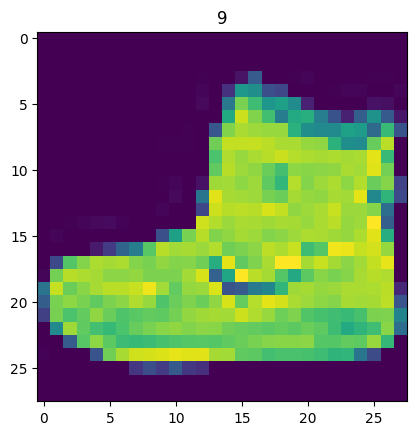

In [ ]:
import matplotlib.pyplot as plt

image, label = train_data[0]
plt.imshow(X=image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

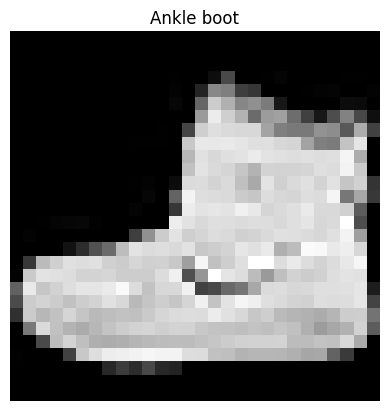

In [ ]:
# lets see it in gray scale
plt.imshow(
    X=image.squeeze(),
    cmap="gray"
)
plt.axis(False)
plt.title(class_names[label])

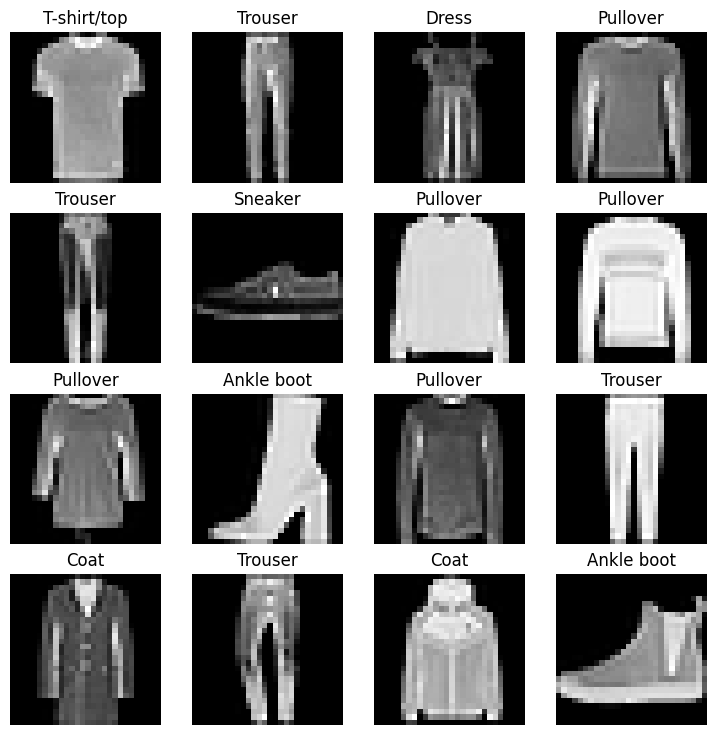

In [ ]:
plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(rows * cols):
  random_index = torch.randint(
    low=0,
    high=len(train_data),
    size=(1,)
  ).item()

  image, label = train_data[random_index]

  plt.subplot(rows, cols, i + 1)
  plt.axis(False)
  plt.imshow(
      X=image.squeeze(),
      cmap="gray"
  )
  plt.title(class_names[label])





Do you think these item of clothing(images) could be modelled with pure linear lines? Or do you think we'll need non-linear lines?

In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

Right now our data is in the form of Pytorch Dataset

DataLoader turns our dataset into python iterable

More specifically, we want to turn our data into batches (or minibatches)

Why would we do this?
1. It is computationally effective, as in, your computing hardware may not be able to look (store in memory) 60000 images in one hit. So we break it down to 32 (common but may be any nnumber u want) images at a time (batch size of 32).
2. Gives our neural network more chances to update its gradients per epoch

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d6f597cab40>,
 <torch.utils.data.dataloader.DataLoader at 0x7d6f59762690>)

In [ ]:
# let's check what we created
print(f"length of train_dataloader {len(train_dataloader)} with batches {BATCH_SIZE}")
print(f"length of test_dataloader {len(test_dataloader)} with batches {BATCH_SIZE}")

length of train_dataloader 1875 with batches 32
length of test_dataloader 313 with batches 32


In [ ]:
# what's inside of train and test data loader
train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

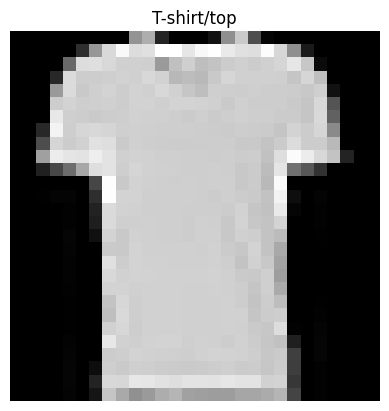

In [ ]:
# visulaize a sample from our batch

torch.manual_seed(42)
random_idx = torch.randint(low=0, high=BATCH_SIZE, size=[1])
random_idx

plt.imshow(X=train_features_batch[random_idx].squeeze(), cmap="gray")
plt.title(class_names[train_labels_batch[random_idx]])
plt.axis(False )

## 3. Model0 : Build a baseline model

When starting to build a machine learning modelling experiments, It's best practice to start with a baseline model

A baseline model is a simple model you will try and improve upon subsequent models/experiments.

In other words, start simply and add complexity when necessary

In [ ]:
from torch import nn

# create a flatten layer
flatten_model = nn.Flatten()

# get a simple
x = train_features_batch[0]

# flatten the sample
output = flatten_model(x) #  forward pass

print(f"shape of sample before flattening: {x.shape}")
print(f"shape of sample after flattening: {output.shape}")

shape of sample before flattening: torch.Size([1, 28, 28])
shape of sample after flattening: torch.Size([1, 784])


In [ ]:
# make model

# torch.manual_seed(42)

class FashionMNISTModelV0(nn.Module):
  def __init__(
      self,
      input_shape: int,
      hidden_units: int,
      output_shape: int,
  ):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
    )

  def forward(self, x):
    return self.linear_layer_stack(x)


model_0 = FashionMNISTModelV0(
      input_shape=784,
      hidden_units=10,
      output_shape=len(class_names)
  ).to("cpu")

model_0

FashionMNISTModelV0(
  (linear_layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
model_0(train_features_batch[0])

tensor([[ 0.2489,  0.1573, -0.1071,  0.0544,  0.0757,  0.4371,  0.3216, -0.4551,
         -0.3458, -0.2140]], grad_fn=<AddmmBackward0>)

### 3.1 set up loss function and optimizer

* loss function - since we are dealing with multi-class classification, we'll use `CrossEntrpyLoss`

* optimizer - `torch.optim.SGD`

* evaluation metrix - accuracy

In [ ]:
from posixpath import isfile
# get the accuracy function

from pathlib import Path
import requests

if(Path("helper_functions.py").is_file()):
  print("helper_functions already exists, skipping download...")
else:
  print("downloading helper_functions.py...")
  response = requests.get("https://raw.githubusercontent.com/Faizan-Rashid/deep-learning-pytorch/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(response.content)
  print("done")

downloading helper_functions.py...
done


In [ ]:
from helper_functions import accuracy_fn

# set up loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.1
)

### 3.1 Creating a function to time our experiments

Machine kearnning is very experimental.

Two of the main things you'll often want to track are

1. Model's perfomance (loss and accuracy values)
2. How fast it runs

In [ ]:
from timeit import default_timer as time

def print_train_time(
    start: float,
    end: float,
    device:torch.device=None
):
  """Prints difference between start and end time"""

  total_time = end - start
  print(f"Train time for device {device}: {total_time}")

In [ ]:
start = time()
# some code...
end = time()

print_train_time(start, end , device="cpu")

Train time for device cpu: 3.959500000405569e-05


### 3.3 creating a training loop and training our model on batches of data

1. Loop through epochs
2. Loop through training batches , perform training steps and calculate train loss *per batch*
3. Loop through the testing batches, perform testing steps and calculate test loss *per batch*
4. print what's happening
5. time it out

In [ ]:
# set the random seed
torch.manual_seed(42)

# Import tqdm for progresss bar
from tqdm.auto import tqdm

# set the number of epochs
epochs = 3

train_start_time_cpu = time()

for epoch in tqdm(range(epochs)):
  ### Training
  model_0.train()
  loss = 0
  for batch, (X, y) in enumerate(train_dataloader):
    # 1. Forward pass
    y_preds = model_0(X)
    # 2. calculate the loss
    train_loss_batch = loss_fn(y_preds, y)
    loss += train_loss_batch
    # 3. optimizer zero grad
    optimizer.zero_grad()
    # 4. perform back propogation
    train_loss_batch.backward()
    # 5. optimizer step (gradient decent)
    optimizer.step()

    if(batch % 300 == 0):
      print(f"batch: {batch} going on")

  # calculate average loss
  loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 1. Forward pass
      y_test_preds = model_0(X_test)
      # 2. Calculate the loss
      test_loss_batch = loss_fn(y_test_preds, y_test)
      test_loss += test_loss_batch
      # 3. Calculate the accuracy
      test_acc_batch = accuracy_fn(y_true=y_test, y_pred=y_test_preds.argmax(dim=1))
      test_acc += test_acc_batch

    # calculate the average accuracy and test loss
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  # Print what's happening
  print(f"epoch: {epoch} | train loss: {loss:.4f} | test loss: {test_loss:.4f} | test accuracy: {test_acc:.4f}")

train_end_time_cpu = time()
print_train_time(start=train_start_time_cpu, end=train_end_time_cpu, device="cpu")

  0%|          | 0/3 [00:00<?, ?it/s]

batch: 0 going on
batch: 300 going on
batch: 600 going on
batch: 900 going on
batch: 1200 going on
batch: 1500 going on
batch: 1800 going on
epoch: 0 | train loss: 0.5948 | test loss: 0.5164 | test accuracy: 81.8391
batch: 0 going on
batch: 300 going on
batch: 600 going on
batch: 900 going on
batch: 1200 going on
batch: 1500 going on
batch: 1800 going on
epoch: 1 | train loss: 0.4795 | test loss: 0.4814 | test accuracy: 83.1769
batch: 0 going on
batch: 300 going on
batch: 600 going on
batch: 900 going on
batch: 1200 going on
batch: 1500 going on
batch: 1800 going on
epoch: 2 | train loss: 0.4570 | test loss: 0.4777 | test accuracy: 83.4964
Train time for device cpu: 41.35312775599999


## 4. Make predictions and get Model 0 results

In [ ]:
def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device:torch.device=device
):
  """evaluates the given model - returns a dictionary containing results of model's prediction on data loader

  Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

  Returns:
        (dict): Results of model making predictions on data_loader."""

  model.eval()
  with torch.inference_mode():
    loss, accuracy = 0, 0
    for X, y in tqdm(data_loader):
      # get the data to target device
      X, y = X.to(device), y.to(device)
      y_preds = model(X)
      # calculate and add loss value
      loss_batch = loss_fn(y_preds, y)
      loss += loss_batch
      # calculate and add accuracy value
      acc = accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))
      accuracy += acc

    # calculate the avergae loss and accuracy
    accuracy /= len(data_loader)
    loss /= len(data_loader)

  return {
      "model_name": model.__class__.__name__,
      "loss":loss,
      "accuracy":accuracy
  }

In [ ]:
model_0_results = eval_model(model=model_0.to(device),
           data_loader=test_dataloader,
           loss_fn=loss_fn,
           accuracy_fn=accuracy_fn,
           device=device)

  0%|          | 0/313 [00:00<?, ?it/s]

## 5. Set up device agnostic code (for using a GPU if there is one)

In [ ]:
torch.cuda.is_available()

True

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [ ]:
!nvidia-smi

Sat Aug  8 13:02:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             25W /   70W |     153MiB /  15360MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 6. Building a model with non-linearity

We learmed about the power of non-linearity

In [ ]:
from torch import nn

class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_features: int,
               hidden_units: int,
               output_features: int):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
        nn.ReLU()
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

In [ ]:
# create instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(
    input_features=784,
    hidden_units=10,
    output_features=len(class_names)
).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Set up loss function and optimizer

In [ ]:
from helper_functions import accuracy_fn
# loss function and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### 6.2 Functionizing training and evaluating (testing) loops

Lets create function for
* training loop - `train_step()`
* testing loop - `test_step()`

In [ ]:
def train_step(model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device=device):
  """Perform training on model trying to learn on data_loader"""

  ### Training
  model.train()
  loss, accuracy = 0, 0
  for batch, (X, y) in enumerate(data_loader):
    # Put the data on target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass (give raw logits)
    y_preds = model(X)

    # 2. calculate the loss and accuracy per batch
    train_loss_batch = loss_fn(y_preds, y)
    loss += train_loss_batch

    acc = accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))
    accuracy += acc

    # 3. optimizer zero grad
    optimizer.zero_grad()

    # 4. perform back propogation
    train_loss_batch.backward()

    # 5. optimizer step (gradient decent)
    optimizer.step()

  # calculate average loss and accuracy
  loss /= len(data_loader)
  accuracy /= len(data_loader)

  # Print
  print(f"Train loss: {loss:.4f} | train accuracy: {accuracy:.4f}")

In [ ]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              accuracy_fn,
              device: torch.device=device):
  """Perform testing on model going over data_loader"""

  ### Testing
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in data_loader:
      # Put the data on target device
      X_test, y_test = X_test.to(device), y_test.to(device)
      # 1. Forward pass
      y_test_preds = model(X_test)
      # 2. Calculate the loss
      test_loss_batch = loss_fn(y_test_preds, y_test)
      test_loss += test_loss_batch
      # 3. Calculate the accuracy
      test_acc_batch = accuracy_fn(y_true=y_test, y_pred=y_test_preds.argmax(dim=1))
      test_acc += test_acc_batch

    # calculate the average accuracy and test loss
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  # Print what's happening
  print(f"Test loss: {test_loss:.4f} | test accuracy: {test_acc:.4f}")


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer

# set epochs
epochs = 3

# Measure timee
train_time_start_on_gpu = timer()

# Create optimization and evaluation loop

for epoch in tqdm(range(epochs)):
  print(f"\nEpoch: {epoch} -----------\n")
  ### Training
  train_step(model=model_1,
             loss_fn=loss_fn,
             optimizer=optimizer,
             data_loader=train_dataloader,
             accuracy_fn=accuracy_fn,
             device=device)

  ### Testing
  test_step(model=model_1,
            loss_fn=loss_fn,
            data_loader=test_dataloader,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_gpu = timer()

print_train_time(start=train_time_start_on_gpu,
                 end=train_time_end_on_gpu,
                 device=device)

  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0 -----------

Train loss: 1.0920 | train accuracy: 61.3433
Test loss: 0.9564 | test accuracy: 64.9960

Epoch: 1 -----------

Train loss: 0.7810 | train accuracy: 71.9283
Test loss: 0.7223 | test accuracy: 73.9117

Epoch: 2 -----------

Train loss: 0.6703 | train accuracy: 75.9367
Test loss: 0.6850 | test accuracy: 75.0200
Train time for device cuda: 50.09374975000003


Our model trained but the training time took longer?

**Note**: The training time on CUDA vs CPU will depend largely on the quality of the CPU/GPU you're using. Read on for a more explained answer.

How to make model compute faster and learn key concepts, A good resource is ,

https://horace.io/brrr_intro

**Question**: "I used a GPU but my model didn't train faster, why might that be?"

**Answer**: Well, one reason could be because your dataset and model are both so small (like the dataset and model we're working with) the benefits of using a GPU are outweighed by the time it actually takes to transfer the data there.

There's a small bottleneck between copying data from the CPU memory (default) to the GPU memory.

So for smaller models and datasets, the CPU might actually be the optimal place to compute on.

But for larger datasets and models, the speed of computing the GPU can offer usually far outweighs the cost of getting the data there.

However, this is largely dependent on the hardware you're using. With practice, you will get used to where the best place to train your models is.

In [ ]:
# Get model_1 results dictionary
model_1_results = eval_model(model=model_1,
           data_loader=test_dataloader,
           loss_fn=loss_fn,
           accuracy_fn=accuracy_fn,
           device=device)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'loss': tensor(0.6850, device='cuda:0'),
 'accuracy': 75.01996805111821}

### 6.3 Results
It seems the model is Overfitting on training data:

Overfitting means our model is learning the training data well but those patterns aren't generalizing to the testing data.

can be prevented by e.g
1. Hold-out
2. Cross-validation
3. Data augmentation
4. Feature selection
5. L1 / L2 regularization
6. Remove layers / number of units per layer
7. Dropout
8. Early stopping

See more about overfitting and how to prevent it:

- https://aws.amazon.com/what-is/overfitting/

- https://medium.com/data-science/8-simple-techniques-to-prevent-overfitting-4d443da2ef7d

Let's implement 2 techniques:

- **Using a smaller or different model** (some models fit certain kinds of data better than others).
- **Using a larger dataset** (the more data, the more chance a model has to learn generalizable patterns).

## 7. Model 2: Building Convolutional Neural Networks


CNN's are known for their capabilities to find patterns in visual data.

Find what is CNN?

https://www.ibm.com/think/topics/convolutional-neural-networks


The CNN model we're going to be using is known as TinyVGG from the CNN Explainer website.

https://poloclub.github.io/cnn-explainer/

In [ ]:
from torch import nn

class FashionMNISTModelV2(nn.Module):
  def __init__(self,
               input_features:int,
               hidden_units: int,
               output_features: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_features,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_features)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    # print(f"output shape of conv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"output shape of conv_block_2: {x.shape}")
    x = self.classifier(x)
    # print(f"output shape of classifier: {x.shape}")
    return x


model_2 = FashionMNISTModelV2(input_features=1,
                              hidden_units=10,
                              output_features=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1 Stepping through `nn.Conv2d()`

In [ ]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64))

test_image = images[0]

print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# create a single 2d layer

conv_layer = nn.Conv2d(in_channels=3,
          out_channels=10,
          kernel_size=3,
          stride=1,
          padding=0)

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

In [ ]:
pool_fn = nn.MaxPool2d(kernel_size=2)

pool_fn(conv_output).shape

torch.Size([10, 31, 31])

In [ ]:
torch.manual_seed(42)

# Create a random tensor with dimensions similar to our images
random_tesnor = torch.rand(size=(1, 1, 2, 2))

# Create a Maxpool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass the random tensor through the maxpool layer
output = max_pool_layer(random_tesnor)
output.shape, output

(torch.Size([1, 1, 1, 1]), tensor([[[[0.9593]]]]))

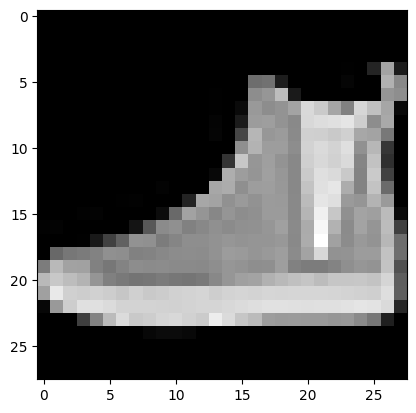

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")

In [ ]:
# let's try to forward pass the image to image to our model
model_2(image.unsqueeze(0).to(device))

tensor([[ 0.0004,  0.0035, -0.0080,  0.0499,  0.1153,  0.0476, -0.0663,  0.0389,
         -0.0050,  0.0588]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 Set up a loss function and Optimizer

In [ ]:
# loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

### 7.4 Training and testing our `model_2` using our training and testing functions

In [ ]:
torch.manual_seed(42)

from timeit import default_timer as timer
from tqdm.auto import tqdm

time_before_train = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"epoch: {epoch}--------------")
  ### Training
  train_step(model=model_2,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             data_loader=train_dataloader,
             device=device)

  ### Testing
  test_step(model=model_2,
            loss_fn=loss_fn,
            data_loader=test_dataloader,
            accuracy_fn=accuracy_fn,
            device=device)

time_after_train = timer()
print_train_time(time_before_train, time_after_train, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0--------------
Train loss: 0.6559 | train accuracy: 76.2083
Test loss: 0.4050 | test accuracy: 85.6230
epoch: 1--------------
Train loss: 0.3621 | train accuracy: 87.0283
Test loss: 0.3496 | test accuracy: 87.4201
epoch: 2--------------
Train loss: 0.3276 | train accuracy: 88.1633
Test loss: 0.3544 | test accuracy: 87.3702
Train time for device cuda: 59.131851720999975


In [ ]:
model_2_results = eval_model(model=model_2,
           data_loader=test_dataloader,
           loss_fn=loss_fn,
           accuracy_fn=accuracy_fn,
           device=device)

  0%|          | 0/313 [00:00<?, ?it/s]

## 8. Comparing model results and training time

In [ ]:
import pandas as pd

results_comparison = pd.DataFrame([model_0_results, model_1_results, model_2_results])
results_comparison

,model_name,loss,accuracy
0,FashionMNISTModelV0,"tensor(0.4777, device='cuda:0')",83.496406
1,FashionMNISTModelV1,"tensor(0.6850, device='cuda:0')",75.019968
2,FashionMNISTModelV2,"tensor(0.3544, device='cuda:0')",87.370208


In [ ]:
results_comparison["training_time"] = [32.025214088999974, 32.946258014999785, 198.05013930199993]
results_comparison

,model_name,loss,accuracy,training_time
0,FashionMNISTModelV0,"tensor(0.4777, device='cuda:0')",83.496406,32.025214
1,FashionMNISTModelV1,"tensor(0.6850, device='cuda:0')",75.019968,32.946258
2,FashionMNISTModelV2,"tensor(0.3544, device='cuda:0')",87.370208,198.050139


<Axes: ylabel='model_name'>

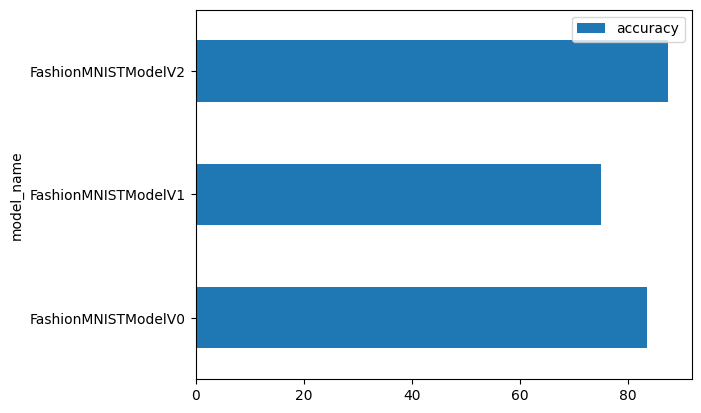

In [ ]:
results_comparison.plot("model_name", "accuracy", kind="barh")

## 9. Make and evaluate random predictions with best model

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [ ]:
import random

test_samples = []
test_labels = []

for img, label in random.sample(list(test_data), k=10):
  test_samples.append(img)
  test_labels.append(label)

In [ ]:
test_samples[0].shape, test_data.classes[test_labels[0]]

(torch.Size([1, 28, 28]), 'Dress')

In [ ]:
predictions = make_predictions(model_2,
                               test_samples)

In [ ]:
predictions[:2]

tensor([[1.4530e-02, 1.9801e-04, 2.5142e-02, 6.4965e-01, 2.8023e-01, 3.0475e-05,
         2.7459e-02, 1.4349e-05, 2.7410e-03, 4.9145e-06],
        [9.5171e-01, 4.2817e-07, 1.9038e-03, 5.4945e-03, 5.1476e-05, 3.3162e-07,
         4.0713e-02, 3.9987e-07, 1.2469e-04, 2.5533e-07]])

In [ ]:
pred_labels = predictions.argmax(dim=1)

In [ ]:
test_labels, pred_labels

([3, 0, 1, 0, 0, 9, 9, 1, 9, 3], tensor([3, 0, 1, 0, 6, 9, 9, 1, 9, 3]))

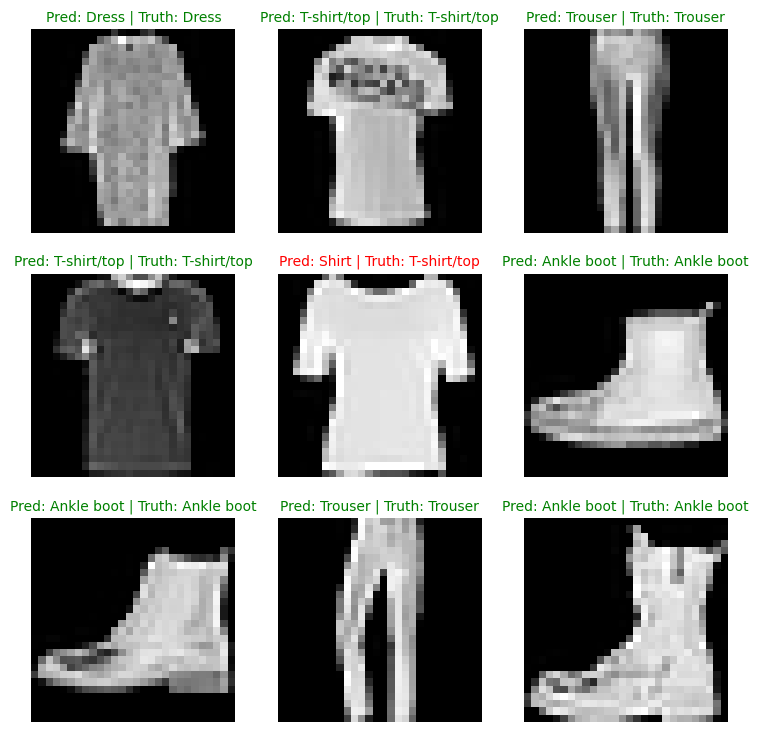

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  if i==9: break

  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_labels[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

## 10. Making a confusion matrix for further prediction evaluation

There are many different evaluation metrics we can use for classification problems.

One of the most visual is a confusion matrix.

A confusion matrix shows you where your classification model got confused between predictions and true labels.

To make a confusion matrix, we'll go through three steps:

1. Make predictions with our trained model, model_2 (a confusion matrix compares predictions to true labels).
2. Make a confusion matrix using `torchmetrics.ConfusionMatrix`.
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`.

In [ ]:
# 1. get the predictions
model_2.to("cpu")
model_2.eval()
predictions = []
labels = []

with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to("cpu"), y.to("cpu")

    labels.append(y)
    pred_logits = model_2(X) # forward pass

    pred_probs = torch.softmax(pred_logits, dim=0).argmax(dim=1)
    predictions.append(pred_probs)

# concatenate list of predictions into tensor
predictions_tensor = torch.cat(predictions)
labels_tensor = torch.cat(labels)

First we'll need to make sure we've got torchmetrics and mlxtend installed (these two libraries will help us make and visualize a confusion matrix).

In [ ]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass", num_classes=len(test_data.classes)).to(device)
confmat_tensor = confmat(predictions_tensor, test_data.targets.to(device))

In [ ]:
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.to("cpu").numpy(), # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);

the torchmetrics has compabiility issue with numpy - needs a specific lower verision and to use it we need to mmanually install numpy lower version and fix error every time notbook starts - So I implemented confusion matrix using sicket learn

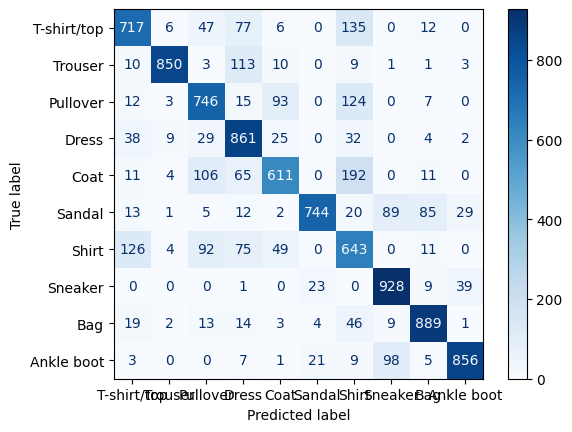

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 15))
conf_mat = confusion_matrix(labels_tensor, predictions_tensor)
display_conf_mat = ConfusionMatrixDisplay(confusion_matrix=conf_mat,
                       display_labels=test_data.classes)
display_conf_mat.plot(cmap=plt.cm.Blues)
plt.show()

## 11. Save and load best performing model

In [ ]:
torch.save(obj=model_2.state_dict(),
           f="best_model.pt")

In [ ]:
model_3 = FashionMNISTModelV2(input_features=1,
                              hidden_units=10,
                              output_features=10)

model_3.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
model_3.to(device)
model_3.eval()
loss , acc = 0, 0
with torch.inference_mode():
  for batch_num, (X, y) in enumerate(test_dataloader):
    X, y = X.to(device), y.to(device)
    preds = model_3(X)
    # print(X.shape, y.shape, preds.shape)
    loss += loss_fn(preds, y)
    acc += accuracy_fn(y, torch.argmax(preds, dim=1))

print(f"loss: {loss / len(test_dataloader)} | accuracy: {acc / len(test_dataloader)}")

loss: 0.3544107973575592 | accuracy: 87.37020766773163


In [ ]:
model_1.to(device)
model_1.eval()
loss , acc = 0, 0
with torch.inference_mode():
  for batch_num, (X, y) in enumerate(test_dataloader):
    X, y = X.to(device), y.to(device)
    preds = model_1(X)
    # print(X.shape, y.shape, preds.shape)
    loss += loss_fn(preds, y)
    acc += accuracy_fn(y, torch.argmax(preds, dim=1))

print(f"loss: {loss / len(test_dataloader)} | accuracy: {acc / len(test_dataloader)}")

loss: 0.6850008964538574 | accuracy: 75.01996805111821
